# Chapter 7 — The Central Limit Theorem

Why averages of almost anything look normal, and how their spread shrinks with n.

| Section | What it covers |
|---|---|
| 7.1 | CLT for sample means |
| 7.2 | The standard error |
| 7.3 | CLT for sums |

**How to use this notebook.** Read a short explanation, run the worked cell under it, then do the
**Your turn** cell yourself. The worked cells already show their output, so you can check your
answer against them. Nothing here is graded and nothing is hidden, so break things freely and
re-run the setup cell if you get lost.

The matching page on the website is [The Central Limit Theorem](https://khh-aka-lucifer.github.io/statLab/chapters/central-limit-theorem/), where the same ideas are
sliders and draggable points instead of code. Use both. The website builds the intuition, and the
notebook shows you how to do it to data of your own.

In [1]:
# Run me first. Everything below needs this cell.
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import stats

# The same colours the StatLab website uses, so your charts match the demos.
C = {
    "accent": "#2E7D6B", "accent_strong": "#1F5A4D", "accent_soft": "#D9EBE5",
    "ink": "#282725", "ink_soft": "#6B6560", "line": "#E4E0DA",
    "cat1": "#2E7D6B", "cat2": "#B5763F", "cat3": "#4E7DA6",
    "cat4": "#9A5D8F", "cat5": "#8A8F3C",
    "ok": "#4C8B57", "warn": "#C06A2E",
}

plt.rcParams.update({
    "figure.figsize": (8, 4.5), "figure.dpi": 110,
    "figure.facecolor": "white", "axes.facecolor": "white",
    "axes.edgecolor": C["line"], "axes.labelcolor": C["ink"],
    "axes.spines.top": False, "axes.spines.right": False,
    "axes.grid": True, "grid.color": C["line"], "grid.linewidth": 0.8,
    "text.color": C["ink"], "xtick.color": C["ink_soft"], "ytick.color": C["ink_soft"],
    "font.size": 11, "axes.titlesize": 12, "legend.frameon": False,
})

# Works whether you launched Jupyter inside code/ or at the repo root.
DATA = Path("data") if Path("data").exists() else Path("code/data")

# One seed, so your numbers match the text. Change it and the randomness changes with you.
rng = np.random.default_rng(12345)

print("Ready. pandas", pd.__version__, "| numpy", np.__version__)

Ready. pandas 3.0.3 | numpy 2.4.4


## The most useful theorem you will meet

Chapter 1 showed that sample means bounce around. Chapter 6 showed that the normal curve is
everywhere. The **central limit theorem** explains why those two facts are connected, and it is what
makes the whole of the rest of the course possible.

To see it properly we need an ugly parent distribution. Seattle rainfall is ideal, because it is
about as far from a bell curve as real data gets.

In [2]:
weather = pd.read_csv(DATA / "seattle-weather.csv", parse_dates=["date"])
rain = weather["precipitation"].to_numpy()

print(f"n = {len(rain)} days")
print(f"mean mu    = {rain.mean():.3f} mm")
print(f"sd sigma   = {rain.std(ddof=0):.3f} mm")
print(f"median     = {np.median(rain):.3f} mm   <- more than half the days are bone dry")
print(f"skewness   = {stats.skew(rain):.3f}   <- a normal curve scores 0")

n = 1461 days
mean mu    = 3.029 mm
sd sigma   = 6.678 mm
median     = 0.000 mm   <- more than half the days are bone dry
skewness   = 3.502   <- a normal curve scores 0


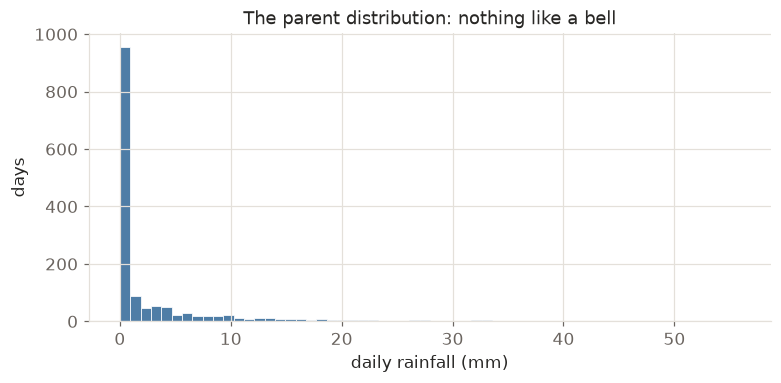

In [3]:
fig, ax = plt.subplots(figsize=(8, 3.4))
ax.hist(rain, bins=60, color=C["cat3"], edgecolor="white", linewidth=0.5)
ax.set_xlabel("daily rainfall (mm)"); ax.set_ylabel("days")
ax.set_title("The parent distribution: nothing like a bell")
plt.show()

## 7.1 CLT for sample means

Draw $n$ days at random, average them, write the average down, and repeat. The theorem says the pile
of averages turns into a normal curve as $n$ grows, no matter what the parent looked like.

Watch it happen.

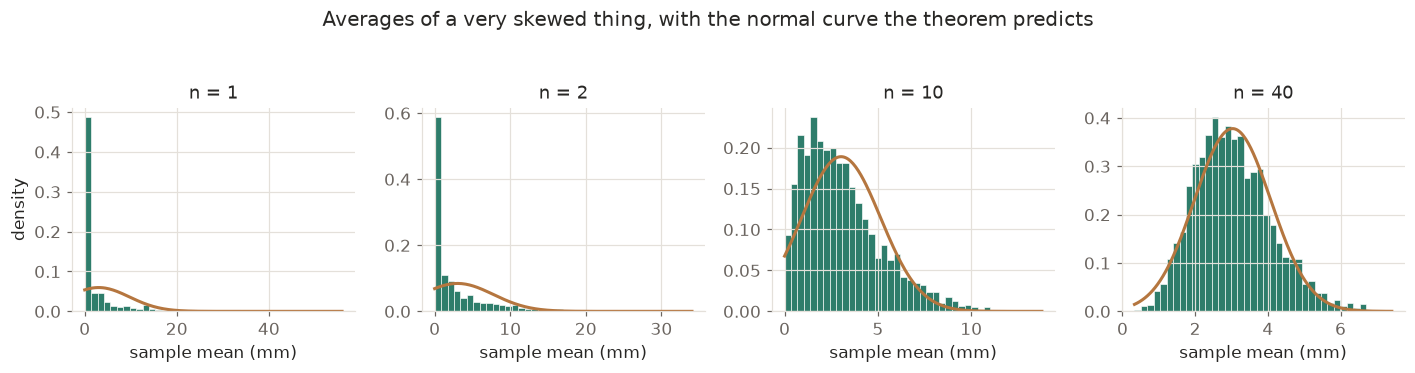

In [4]:
def sample_means(data, n, reps=3000):
    draws = rng.choice(data, size=(reps, n), replace=True)
    return draws.mean(axis=1)

sizes = [1, 2, 10, 40]
piles = {n: sample_means(rain, n) for n in sizes}

fig, axes = plt.subplots(1, 4, figsize=(13, 3.2))
for ax, n in zip(axes, sizes):
    values = piles[n]
    ax.hist(values, bins=40, density=True, color=C["accent"], edgecolor="white", linewidth=0.4)

    grid = np.linspace(values.min(), values.max(), 200)
    ax.plot(grid, stats.norm.pdf(grid, rain.mean(), rain.std(ddof=0) / np.sqrt(n)),
            color=C["cat2"], lw=2)
    ax.set_title(f"n = {n}"); ax.set_xlabel("sample mean (mm)")
axes[0].set_ylabel("density")

fig.suptitle("Averages of a very skewed thing, with the normal curve the theorem predicts", y=1.05)
plt.tight_layout()
plt.show()

At $n = 1$ the "average" is just a single day, so you get the parent back, spike at zero and all.
By $n = 10$ the spike has gone. By $n = 40$ it is a bell.

The orange curve is not fitted to the bars. It is $N(\mu, \sigma/\sqrt{n})$, drawn from the parent's
own mean and standard deviation before any sampling happened, and the bars walk into it.

In [5]:
for n in sizes:
    values = piles[n]
    print(f"n = {n:2d}   mean of means {values.mean():6.3f}   sd of means {values.std(ddof=1):6.3f}"
          f"   skewness {stats.skew(values):6.3f}")
print(f"\nparent: mean {rain.mean():.3f}, sd {rain.std(ddof=0):.3f}, skewness {stats.skew(rain):.3f}")

n =  1   mean of means  3.025   sd of means  6.604   skewness  3.352
n =  2   mean of means  2.978   sd of means  4.763   skewness  2.538
n = 10   mean of means  3.107   sd of means  2.157   skewness  1.103
n = 40   mean of means  3.037   sd of means  1.068   skewness  0.537

parent: mean 3.029, sd 6.678, skewness 3.502


Two things to read off that table. The mean of the sample means stays put at the parent mean for
every $n$, so averaging is **unbiased**. And the skewness falls from 3.4 towards 0 as $n$ grows,
which is the theorem working in a single column of numbers.

In [ ]:
# Your turn.
# Repeat the experiment with the `wind` column instead of rainfall.
# Wind is much less skewed to begin with. Does it need a smaller n to look normal?
# Print the skewness of the sample means at n = 1, 2, 5, 10 for both columns and compare.

...

## 7.2 The standard error

The standard deviation of the sample means has its own name, the **standard error**, and its own
formula,

$$SE = \frac{\sigma}{\sqrt{n}}$$

The square root is the important part and it is bad news. To halve your uncertainty you need four
times as much data. To cut it to a tenth you need a hundred times as much.

In [6]:
ns = np.array([2, 5, 10, 25, 50, 100, 200, 400])
observed = np.array([sample_means(rain, n, reps=2000).std(ddof=1) for n in ns])
formula = rain.std(ddof=0) / np.sqrt(ns)

comparison = pd.DataFrame({"n": ns, "observed SE": observed.round(4), "sigma/sqrt(n)": formula.round(4)})
comparison

,n,observed SE,sigma/sqrt(n)
0,2,4.7451,4.7220
1,5,2.9707,2.9865
2,10,2.1287,2.1117
3,25,1.3114,1.3356
4,50,0.9357,0.9444
5,100,0.6803,0.6678
6,200,0.4687,0.4722
7,400,0.3307,0.3339


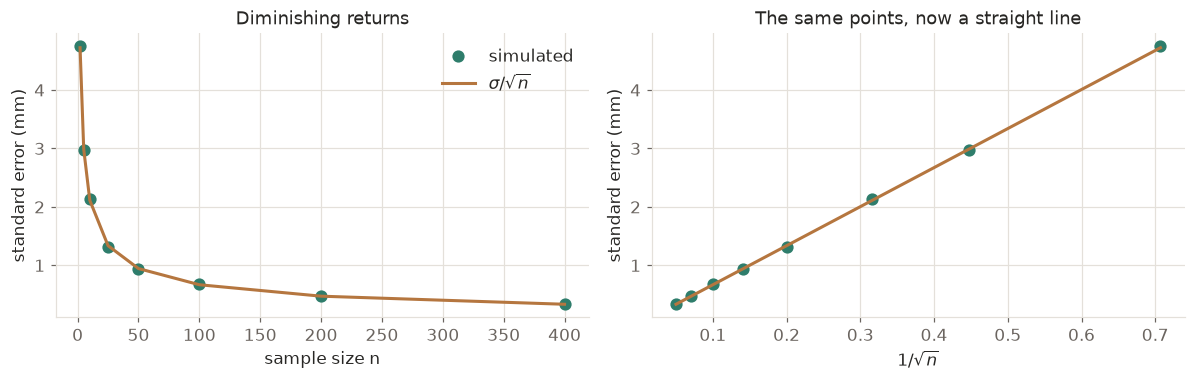

In [7]:
fig, (left, right) = plt.subplots(1, 2, figsize=(11, 3.6))

left.plot(ns, observed, "o", color=C["accent"], ms=7, label="simulated")
left.plot(ns, formula, color=C["cat2"], lw=2, label=r"$\sigma/\sqrt{n}$")
left.set_xlabel("sample size n"); left.set_ylabel("standard error (mm)")
left.set_title("Diminishing returns"); left.legend()

right.plot(1 / np.sqrt(ns), observed, "o", color=C["accent"], ms=7)
right.plot(1 / np.sqrt(ns), formula, color=C["cat2"], lw=2)
right.set_xlabel(r"$1/\sqrt{n}$"); right.set_ylabel("standard error (mm)")
right.set_title("The same points, now a straight line")

plt.tight_layout()
plt.show()

The left panel is the honest picture of what more data buys you, and it flattens out fast. The right
panel is the same numbers plotted against $1/\sqrt{n}$, where they fall on a straight line through
the origin, which is what the formula claims.

There is one catch that matters in practice. The formula needs $\sigma$, the population standard
deviation, and you almost never have it. In real work you substitute the sample standard deviation
$s$, and that substitution is exactly what Chapter 8 has to pay for.

In [ ]:
# Your turn.
# You are planning a survey and want the standard error of the mean rainfall below 0.5 mm.
# 1. Use the formula to work out the n you need.
# 2. Check it by simulation.
# 3. Now work out the n for an SE below 0.25 mm. How many times bigger is it?

sigma = rain.std(ddof=0)
...

## 7.3 CLT for sums

Totals behave the same way, with one sign flipped. A sum of $n$ draws has mean $n\mu$ and standard
deviation $\sigma\sqrt{n}$, so the spread of a total **grows** with $n$ while the spread of an
average shrinks. Both come from the same $\sqrt{n}$.

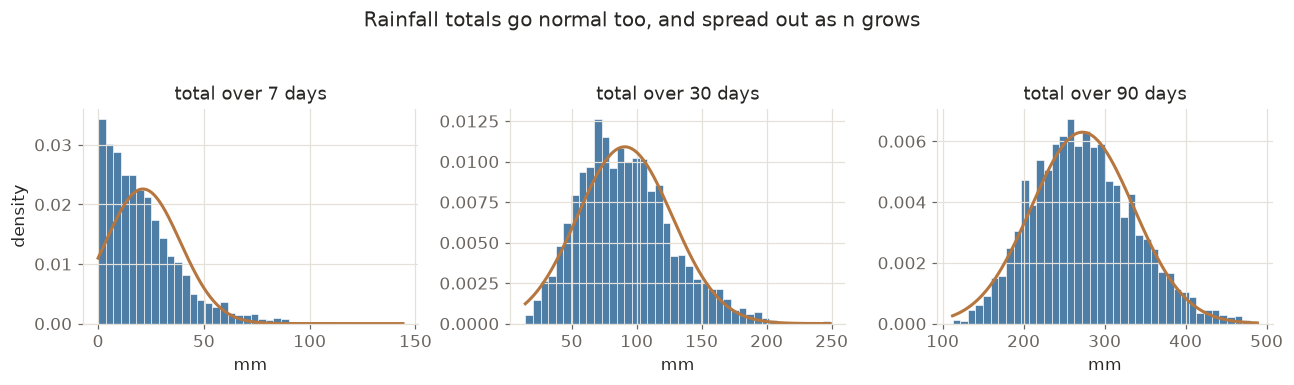

  7 days: mean    21.43 (formula    21.21)   sd   17.96 (formula   17.67)
 30 days: mean    91.47 (formula    90.88)   sd   36.13 (formula   36.58)
 90 days: mean   274.33 (formula   272.65)   sd   63.09 (formula   63.35)


In [8]:
totals = {n: rng.choice(rain, size=(3000, n), replace=True).sum(axis=1) for n in [7, 30, 90]}

fig, axes = plt.subplots(1, 3, figsize=(12, 3.3))
for ax, (n, values) in zip(axes, totals.items()):
    ax.hist(values, bins=40, density=True, color=C["cat3"], edgecolor="white", linewidth=0.4)
    grid = np.linspace(values.min(), values.max(), 200)
    ax.plot(grid, stats.norm.pdf(grid, n * rain.mean(), rain.std(ddof=0) * np.sqrt(n)),
            color=C["cat2"], lw=2)
    ax.set_title(f"total over {n} days"); ax.set_xlabel("mm")
axes[0].set_ylabel("density")

fig.suptitle("Rainfall totals go normal too, and spread out as n grows", y=1.05)
plt.tight_layout()
plt.show()

for n, values in totals.items():
    print(f"{n:3d} days: mean {values.mean():8.2f} (formula {n*rain.mean():8.2f})   "
          f"sd {values.std(ddof=1):7.2f} (formula {rain.std(ddof=0)*np.sqrt(n):7.2f})")

This is why monthly rainfall totals are far better behaved than daily ones, and why measurement
errors, which are sums of many small independent nudges, are so reliably normal. Anything that is
secretly a sum of many small things tends to look like a bell curve, whatever the small things
looked like.

In [ ]:
# Your turn.
# Total the rainfall for each real calendar month in the data (there are 48 of them) and
# QQ plot those 48 totals against a normal.
# Real months are not random draws, so this is a genuine test rather than a simulation.
# Does the CLT survive contact with reality here?

weather["month"] = weather["date"].dt.to_period("M")
...

## Exercises

1. **How big is big enough.** The old rule of thumb is $n \ge 30$. Test it. For rainfall, find the
   smallest $n$ where the sample means pass a normality test (`stats.shapiro`) most of the time.
   Then do the same for `temp_max`, which starts out much closer to normal. One number cannot serve
   both, so what does the rule of thumb actually depend on?

2. **A parent with no mean.** Draw from a Cauchy distribution with `rng.standard_cauchy` and average
   it. The CLT does not apply, because a Cauchy has no finite mean or variance. Plot the sample means
   at $n = 1, 10, 100$ and watch the theorem fail. This is the exception worth having seen.

3. **Proportions are means.** A proportion is the mean of a column of zeros and ones. Take Titanic
   `survived`, draw samples of 25 and 100, and confirm the sample proportions go normal with standard
   error $\sqrt{p(1-p)/n}$.

4. **Sampling without replacement.** Redo section 7.1 with `replace=False`. For small $n$ relative to
   the population, nothing changes. Push $n$ towards 1461 and the standard error collapses towards
   zero. Explain why, and look up the finite population correction.

5. **Your own parent.** Build a deliberately awful distribution, such as a mixture of two far-apart
   spikes, and find the $n$ at which its sample means look normal.

## What you should take away

Averages of almost anything become normal as the sample grows, centred on the true mean with a
spread of $\sigma/\sqrt{n}$. You watched it happen to Seattle rainfall, which is about as unbell-like
as real data gets.

The $\sqrt{n}$ is the practical sting. Precision is expensive and gets more expensive, so "collect
more data" has a price tag you can now compute. And the standard error is the quantity every
confidence interval and every test in the rest of the course is built on.

---

*StatLab, by Dr. Sein Minn and Kaung Hein Htet. Code MIT, text CC BY 4.0.
Follows OpenStax [Introductory Statistics](https://openstax.org) (Illowsky & Dean, CC BY 4.0).*